# 6CS012 - Artificial Intelligence and Machine Learning
## Worksheet 5: Implementation of Convolutional Neural Network using Keras

---



## 0. Mount Google Drive & Import Libraries

In [10]:
# Mount Google Drive (run this cell to access your dataset)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.metrics import classification_report

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## Dataset Configuration

!unzip "/content/drive/MyDrive/AIML/Week5/FruitinAmazon.zip" -d "/content/drive/MyDrive/AIML/Week5"

In [13]:


TRAIN_DIR       = '/content/drive/MyDrive/AIML/Week5/FruitinAmazon/train'    # ← Update to your train folder
TEST_DIR        = '/content/drive/MyDrive/AIML/Week5/FruitinAmazon/test'     # ← Update to your test folder

IMG_HEIGHT      = 128
IMG_WIDTH       = 128
BATCH_SIZE      = 16
VALIDATION_SPLIT = 0.2

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Task 1: Data Understanding and Visualization

### 1.1 Load and Visualize One Image Per Class

Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


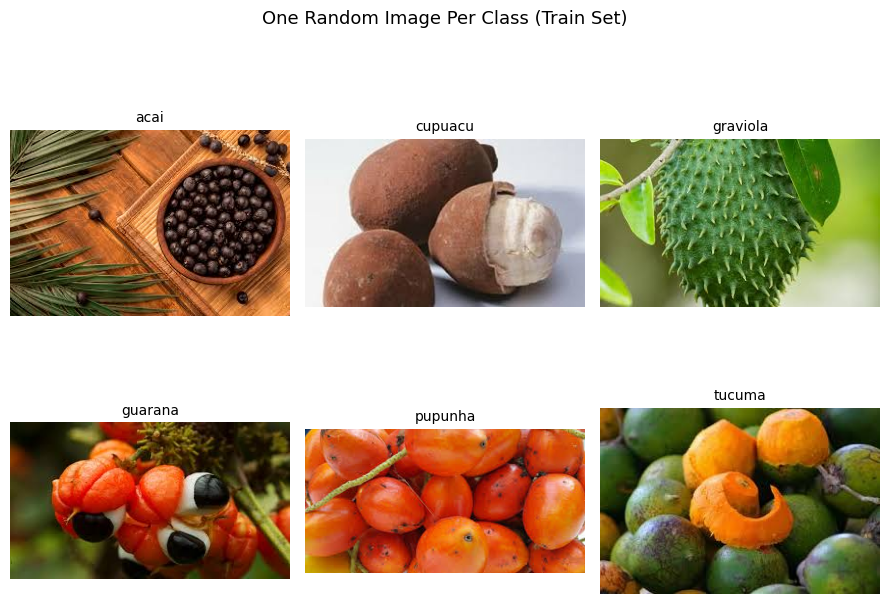

In [15]:
# Get the list of class directories from the train folder
class_dirs = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])
num_classes = len(class_dirs)
print(f'Classes found ({num_classes}): {class_dirs}')

# Select one image randomly from each class
sample_images = []
sample_labels = []
for class_name in class_dirs:
    class_path = os.path.join(TRAIN_DIR, class_name)
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    chosen = random.choice(image_files)
    sample_images.append(os.path.join(class_path, chosen))
    sample_labels.append(class_name)

# Display images in a grid with two rows using matplotlib
ncols = int(np.ceil(num_classes / 2))
fig, axes = plt.subplots(2, ncols, figsize=(ncols * 3, 7))
axes = axes.flatten()

for i, (img_path, label) in enumerate(zip(sample_images, sample_labels)):
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=10)
    axes[i].axis('off')

# Hide any unused subplot slots
for j in range(len(sample_images), len(axes)):
    axes[j].axis('off')

plt.suptitle('One Random Image Per Class (Train Set)', fontsize=13)
plt.tight_layout()
plt.show()

**What did you Observe?**

The images vary significantly across classes in terms of colour, texture, size, and background. For example:
- **Pupunha** and **tucuma** are orange/yellow fruits often shown in clusters.
- **Guarana** has small red-orange berries.
- **Graviola** is a large green spiky fruit.
- **Acai** consists of small dark purple berries.
- **Cupuacu** is a large brown pod.

The images also differ in resolution and aspect ratio, and some have cluttered backgrounds. These variations make it a challenging classification task that benefits from convolutional feature extraction.

### 1.2 Check for Corrupted Images

In [16]:
corrupted_images = []

# Iterate through each class subdirectory in the train folder
for class_name in class_dirs:
    class_path = os.path.join(TRAIN_DIR, class_name)
    for filename in os.listdir(class_path):
        image_path = os.path.join(class_path, filename)
        try:
            img = Image.open(image_path)
            img.verify()   # Verify the image is not corrupted
        except (IOError, SyntaxError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f'Removed corrupted image: {image_path}')

if len(corrupted_images) == 0:
    print('No corrupted images found.')

No corrupted images found.


---
## Task 2: Loading and Preprocessing Image Data in Keras

In [17]:
# Preprocessing layer: normalise pixel values to [0, 1]
rescale = tf.keras.layers.Rescaling(1./255)

# Create training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=123
)

# Apply normalisation to training dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=123
)

# Apply normalisation to validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Create test dataset (no split, no shuffle)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Apply normalisation to test dataset
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Retrieve class names from the training dataset
class_names = train_ds.class_names if hasattr(train_ds, 'class_names') else class_dirs
print('Class names:', class_names)
print('Number of classes:', len(class_names))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


---
## Task 3: Implement the CNN Model

Architecture as specified:
- **Conv Layer 1**: 32 filters, (3,3), padding=same, stride=1, ReLU
- **MaxPooling 1**: (2,2), stride=2
- **Conv Layer 2**: 32 filters, (3,3), padding=same, stride=1, ReLU
- **MaxPooling 2**: (2,2), stride=2
- **Flatten**
- **Dense Hidden 1**: 64 neurons
- **Dense Hidden 2**: 128 neurons
- **Output**: num_classes neurons, softmax

In [18]:
num_classes = len(class_names)

model = keras.Sequential([
    # Input
    keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Convolutional Layer 1
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', activation='relu'),
    # Pooling Layer 1
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Convolutional Layer 2
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', activation='relu'),
    # Pooling Layer 2
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Flatten
    layers.Flatten(),

    # Hidden Layer 1
    layers.Dense(64, activation='relu'),

    # Hidden Layer 2
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax'),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4: Compile the Model

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled.')
print('  Optimizer : Adam')
print('  Loss      : sparse_categorical_crossentropy')
print('  Metrics   : accuracy')

Model compiled.
  Optimizer : Adam
  Loss      : sparse_categorical_crossentropy
  Metrics   : accuracy


## Task 4: Train the Model

In [20]:
epochs = 250

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='model_at_epoch_{epoch}.keras'
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4
    ),
]

history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 366ms/step - accuracy: 0.2222 - loss: 2.4094 - val_accuracy: 0.0000e+00 - val_loss: 2.1863
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 296ms/step - accuracy: 0.2917 - loss: 1.7546 - val_accuracy: 0.3333 - val_loss: 1.6615
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - accuracy: 0.3472 - loss: 1.6900 - val_accuracy: 0.6667 - val_loss: 1.4907
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 306ms/step - accuracy: 0.3194 - loss: 1.5667 - val_accuracy: 0.3889 - val_loss: 1.5949
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 305ms/step - accuracy: 0.5694 - loss: 1.3142 - val_accuracy: 0.7222 - val_loss: 1.0163
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 514ms/step - accuracy: 0.5694 - loss: 1.1094 - val_accuracy: 0.8333 - val_loss: 0.8422
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 437ms/step - accuracy: 0.6667 - loss: 0.8487 - val_accuracy: 0.6111 - val_loss: 0.9575
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 319ms/step - accuracy: 0.8889 - loss: 0.5364 - val_accuracy: 0.7778

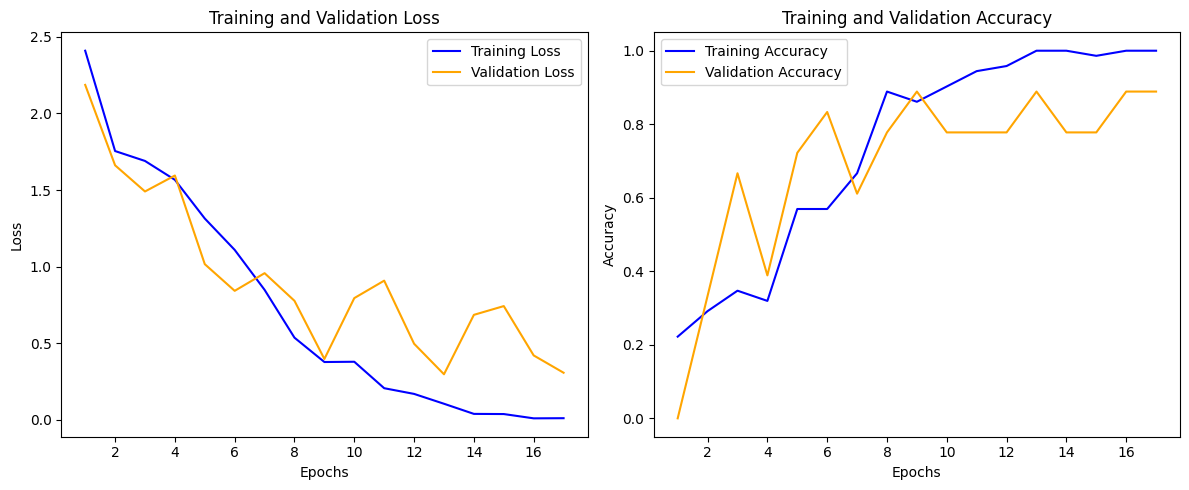

In [21]:
# Visualise training and validation loss and accuracy
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss',   color='blue')
plt.plot(range(1, len(val_loss)   + 1), val_loss,   label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy',   color='blue')
plt.plot(range(1, len(val_acc)   + 1), val_acc,   label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

---
## Task 5: Evaluate the Model

In [22]:
test_loss, test_acc = model.evaluate(test_ds, verbose=2)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

2/2 - 0s - 135ms/step - accuracy: 0.6000 - loss: 1.1745

Test Loss     : 1.1745
Test Accuracy : 0.6000


---
## Task 6: Save and Load the Model

In [23]:
# Save the trained model
model.save('cnn_fruit_classification_model.h5')
print('Model saved to: cnn_fruit_classification_model.h5')

Model saved to: cnn_fruit_classification_model.h5


In [24]:
# Load the saved model
loaded_model = tf.keras.models.load_model('cnn_fruit_classification_model.h5')
print('Model loaded successfully.')

# Re-evaluate the loaded model on the test set
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=2)
print(f'\nLoaded Model — Test Loss     : {loaded_loss:.4f}')
print(f'Loaded Model — Test Accuracy : {loaded_acc:.4f}')

Model loaded successfully.
2/2 - 1s - 288ms/step - accuracy: 0.6000 - loss: 1.1745

Loaded Model — Test Loss     : 1.1745
Loaded Model — Test Accuracy : 0.6000


---
## Task 7: Predictions and Classification Report

In [25]:
# Collect all true labels from the test dataset
y_true = np.concatenate([y.numpy() for _, y in test_ds])

# Make predictions on test data
predictions = model.predict(test_ds)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

print(f'Predicted label for first test image: {predicted_labels[0]}')
print(f'True label for first test image     : {y_true[0]}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Predicted label for first test image: 0
True label for first test image     : 0


In [26]:
# Classification Report
print('Classification Report:')
print(classification_report(y_true, predicted_labels, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       1.00      0.60      0.75         5
    graviola       0.62      1.00      0.77         5
     guarana       0.40      0.40      0.40         5
     pupunha       0.50      0.20      0.29         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.60        30
   macro avg       0.61      0.60      0.57        30
weighted avg       0.61      0.60      0.57        30

